# Load Packages and Data

In [1]:
import importlib
import pitch_suggestions

importlib.reload(pitch_suggestions)

<module 'pitch_suggestions' from '/Users/kids/Pitcher Similarity/pitch_suggestions.py'>

In [ ]:
from data import build_all
from pitch_suggestions import suggest_pitches, plot_pitch_clusters
from pitch_suggestions import _find_target, _find_biomech_comps, _collect_pitches, _tag_novelty, _cluster_novel
import warnings
import pandas as pd

from biomech import compute_euclidean_distances

pd.set_option('display.max_columns', None)

warnings.filterwarnings("ignore")

In [3]:
data = build_all(live=False)

statcast_clean  = data['statcast_clean']
pitch_type_summ = data['pitch_type_summ']
pitcher_summ    = data['pitcher_summ']
pitcher_summ_r  = data['pitcher_summ_r']
pitcher_summ_l  = data['pitcher_summ_l']
pitch_type_r  = data['pitch_type_r']
pitch_type_l  = data['pitch_type_l']

statcast_clean_25 = statcast_clean[statcast_clean['game_year'] == 2025]

def pid(name, pool):
    """Resolve a player name to its unique pitcher id within a pitcher_summ pool."""
    ids = pool.loc[pool['player_name'] == name, 'pitcher'].unique()
    if len(ids) != 1:
        raise ValueError(f"{name!r} maps to {len(ids)} pitcher ids: {sorted(ids)}")
    return int(ids[0])


# Identify Pitch Opportunities

In [4]:
BIOMECH_FEATURES    = ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball']
PITCH_CHAR_FEATURES = ['release_speed', 'pfx_x', 'pfx_z']

### Bello Example

Example of what the tool recommends

In [5]:
b_bello = suggest_pitches(
    target_pitcher_id=pid('Bello, Brayan', pitcher_summ_r),
    pitcher_summ=pitcher_summ_r,
    pitch_type_summ=pitch_type_r,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [6]:
b_bello['status']

'ok'

In [7]:
b_bello['target_info']

pitcher                        678394
p_throws                            R
player_name             Bello, Brayan
game_year                        2025
release_pos_x               -1.657082
release_pos_z                5.323063
release_extension            6.342714
arm_angle                   32.793504
n                                2697
max_velo                    95.301591
max_spin                  2479.262411
pri_fb                             SI
fb_pfx_x                    -1.408565
fb_n                            943.0
pri_fb_cd                           0
active_spin_fastball             80.8
FB_type                            FF
Name: 3106, dtype: object

In [8]:
b_bello['comps'].sort_values('comp_pitcher')[20:25]

,comp_pitcher,comp_year,distance
18,"Beasley, Jeremy",2021,0.538652
208,"Bellatti, Andrew",2023,1.284690
273,"Bender, Anthony",2024,1.415107
197,"Berríos, José",2022,1.257038
211,"Bickford, Phil",2022,1.296000


In [9]:
print(b_bello['comp_pitches'].shape)
b_bello['comp_pitches'].head()

(85, 19)


,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,_dist_to_centroid,_cluster_median_dist,_cluster_mad,_outlier_threshold,cluster_label,biomech_distance,sim_weight
0,"Duffey, Tyler",2021,CS,73.983721,0.961163,-1.079070,43,1052,0.040875,2.289734,ST,0,0.972031,0.540745,0.142131,1.0,CU,1.135869,0.880382
1,"Scherzer, Max",2021,CU,76.863538,1.120650,-0.661625,277,2821,0.098192,1.625124,ST,0,0.754822,0.540745,0.142131,1.0,CU,1.168811,0.855570
2,"Mikolas, Miles",2024,CU,76.587580,0.664395,-1.182548,314,2697,0.116426,2.021034,ST,0,0.629429,0.540745,0.142131,1.0,CU,1.306019,0.765685
3,"Smith, Burch",2024,CU,79.996951,0.920366,-1.140183,164,896,0.183036,1.574829,ST,0,0.184582,0.540745,0.142131,1.0,CU,1.443101,0.692952
4,"Bard, Luke",2022,CU,78.114583,1.588542,-0.021458,48,241,0.199170,1.599177,ST,1,0.432669,0.534619,0.101949,1.0,ST,0.857655,1.165969


In [10]:
b_bello['suggestions']

,cluster_label,cluster,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,pitch_types_in_cluster,comp_pitchers
0,CU,0,68,79.7,0.88,-1.02,1.56,79.8,0.88,-1.02,"CS, CU, KC","Adams, Travis, Antone, Tejay, Avila, Pedro, Ba..."
1,ST,1,17,79.9,1.40,0.13,1.42,79.8,1.41,0.12,"CU, SL, ST","Adam, Jason, Bard, Luke, Barraclough, Kyle, Ba..."


In [11]:
b_bello['target_pitches']

,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n
0,"Bello, Brayan",2025,CH,88.787073,-1.336869,0.377049,410
1,"Bello, Brayan",2025,FC,88.241371,0.072411,0.215721,423
2,"Bello, Brayan",2025,FF,95.075980,-0.638393,1.126201,408
3,"Bello, Brayan",2025,SI,95.301591,-1.408565,0.471697,943
4,"Bello, Brayan",2025,ST,85.676608,0.825887,-0.265263,513


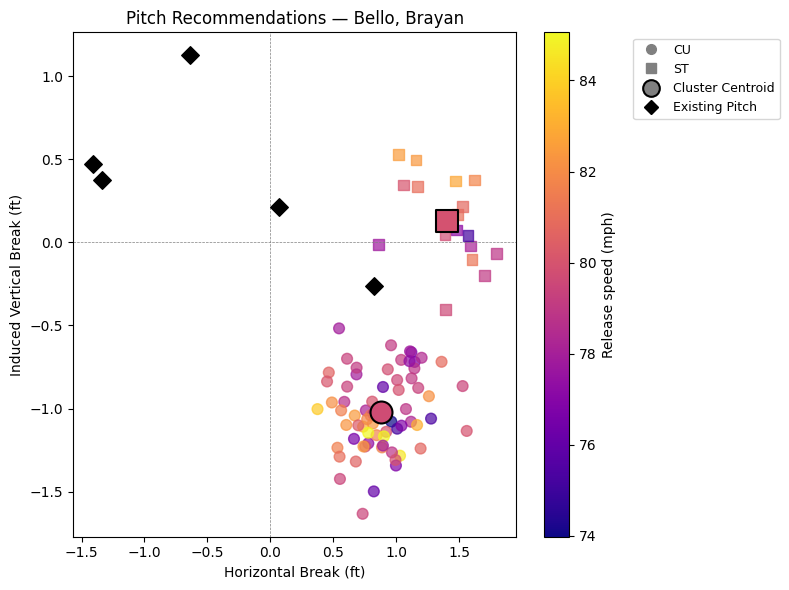

In [12]:
plot_pitch_clusters(b_bello)

In [13]:
b_bello['comp_pitches'].sort_values('_dist_to_centroid', ascending=False)

,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,_dist_to_centroid,_cluster_median_dist,_cluster_mad,_outlier_threshold,cluster_label,biomech_distance,sim_weight
0,"Duffey, Tyler",2021,CS,73.983721,0.961163,-1.079070,43,1052,0.040875,2.289734,ST,0,0.972031,0.540745,0.142131,1.0,CU,1.135869,0.880382
26,"France, J.P.",2023,CU,76.013576,0.821954,-1.498841,302,2202,0.137148,2.394526,ST,0,0.926491,0.540745,0.142131,1.0,CU,1.437784,0.695514
60,"Nelson, Jimmy",2021,KC,85.056667,0.902556,-1.167667,180,523,0.344168,1.293088,ST,0,0.924733,0.540745,0.142131,1.0,CU,1.344642,0.743692
66,"Schmidt, Clarke",2025,KC,85.017489,0.777489,-1.146099,223,1226,0.181892,1.261135,ST,0,0.919665,0.540745,0.142131,1.0,CU,1.171794,0.853391
39,"Nance, Tommy",2024,CU,84.568595,1.030165,-1.283719,121,322,0.375776,1.482836,ST,0,0.917428,0.540745,0.142131,1.0,CU,0.827279,1.208781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,"Smith, Burch",2024,CU,79.996951,0.920366,-1.140183,164,896,0.183036,1.574829,ST,0,0.184582,0.540745,0.142131,1.0,CU,1.443101,0.692952
6,"Taillon, Jameson",2021,CU,80.702428,0.848543,-1.047991,453,2372,0.190978,1.394694,ST,0,0.176322,0.540745,0.142131,1.0,CU,1.378091,0.725641
43,"Burnes, Corbin",2025,CU,80.033505,0.809021,-0.958557,194,1009,0.192270,1.370430,ST,0,0.133574,0.540745,0.142131,1.0,CU,1.052448,0.950165
77,"Eflin, Zach",2023,ST,79.710377,1.386509,0.045189,106,2577,0.041133,1.282713,ST,1,0.126824,0.534619,0.101949,1.0,ST,1.191653,0.839170


### Step Guide

In [14]:
target_row, target_year = _find_target(pitcher_summ_l, pid('Beeks, Jalen', pitcher_summ_l))

In [15]:
target_dists = _find_biomech_comps(
    pitcher_summ_l, pid('Beeks, Jalen', pitcher_summ_l), target_year,
    BIOMECH_FEATURES, biomech_distance_threshold=1.5, min_pitches=20,
)

In [16]:
target_pitches, comp_pitches = _collect_pitches(
    pitch_type_l, target_pitcher_id=pid('Beeks, Jalen', pitcher_summ_l), target_year=target_year, target_dists=target_dists,
    pitch_features=PITCH_CHAR_FEATURES, min_comp_usage_pct=0.01, min_pitches=20
)

In [17]:
from sklearn.preprocessing import StandardScaler
global_scaler = StandardScaler().fit(
    pitch_type_l[PITCH_CHAR_FEATURES].dropna().values
)

In [18]:
comp_pitches, novel = _tag_novelty(
    target_pitches, comp_pitches, PITCH_CHAR_FEATURES, novelty_distance_threshold=1.2, global_scaler=global_scaler
)

In [19]:
print(novel.shape)
novel.head()

(101, 11)


,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch
2,"Alvarez, Jose",2021,CH,81.165441,1.201103,0.359853,272,970,0.280412,1.463415,CH
14,"Gomber, Austin",2022,CH,82.039227,0.814779,0.878923,362,2059,0.175814,1.297258,CH
20,"Means, John",2021,CH,83.392114,1.070599,1.413675,634,2328,0.272337,1.298609,CH
39,"Montgomery, Jordan",2021,CH,82.484505,0.811470,1.225719,626,2570,0.243580,1.366072,CH
40,"Suarez, José",2025,CH,83.341667,1.266190,0.266071,84,295,0.284746,1.228495,CH


In [20]:
novel = _cluster_novel(novel, global_scaler, PITCH_CHAR_FEATURES)

In [21]:
novel

,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n,total_n,usage_pct,min_dist_to_target,closest_target_pitch,cluster,_dist_to_centroid,_cluster_median_dist,_cluster_mad,_outlier_threshold,cluster_label
0,"Alvarez, Jose",2021,CH,81.165441,1.201103,0.359853,272,970,0.280412,1.463415,CH,1,1.176168,1.035685,0.161289,1.519551,CH
1,"Gomber, Austin",2022,CH,82.039227,0.814779,0.878923,362,2059,0.175814,1.297258,CH,1,0.654165,1.035685,0.161289,1.519551,CH
2,"Means, John",2021,CH,83.392114,1.070599,1.413675,634,2328,0.272337,1.298609,CH,1,1.220050,1.035685,0.161289,1.519551,CH
3,"Montgomery, Jordan",2021,CH,82.484505,0.811470,1.225719,626,2570,0.243580,1.366072,CH,1,0.906973,1.035685,0.161289,1.519551,CH
4,"Suarez, José",2025,CH,83.341667,1.266190,0.266071,84,295,0.284746,1.228495,CH,1,1.155413,1.035685,0.161289,1.519551,CH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,"Ragans, Cole",2025,KC,80.087681,-0.960580,-1.088188,138,1079,0.127896,2.030740,FC,0,0.537573,0.629107,0.186234,1.187809,CU
85,"Cleavinger, Garrett",2023,SL,81.329293,-1.025960,-0.596061,99,211,0.469194,1.452851,FC,0,0.876354,0.629107,0.186234,1.187809,CU
86,"Skubal, Tarik",2022,SL,89.345008,-0.092978,0.683570,591,1914,0.308777,1.253861,FC,1,1.021735,1.035685,0.161289,1.519551,CH
87,"Harris, Hogan",2025,ST,78.180000,-0.982571,-0.490571,35,1125,0.031111,1.592499,FC,0,0.766629,0.629107,0.186234,1.187809,CU


## Testing

In [25]:
s_peralta = suggest_pitches(
    target_pitcher_id=pid('Peralta, Sammy', pitcher_summ_l),
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [26]:
e_lauer = suggest_pitches(
    target_pitcher_id=pid('Lauer, Eric', pitcher_summ_l),
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [27]:
r_hill = suggest_pitches(
    target_pitcher_id=pid('Hill, Rich', pitcher_summ_l),
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [28]:
p_corbin = suggest_pitches(
    target_pitcher_id=pid('Corbin, Patrick', pitcher_summ_l),
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [29]:
t_alexander = suggest_pitches(
    target_pitcher_id=pid('Alexander, Tyler', pitcher_summ_l),
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=True
)

In [30]:
j_beeks = suggest_pitches(
    target_pitcher_id=pid('Beeks, Jalen', pitcher_summ_l),
    pitcher_summ=pitcher_summ_l,
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20,
    mask=False
)

In [31]:
r_garcia = suggest_pitches(
    target_pitcher_id=pid('Garcia, Robert', pitcher_summ_l),
    pitcher_summ=pitcher_summ_l,        
    pitch_type_summ=pitch_type_l,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.2,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

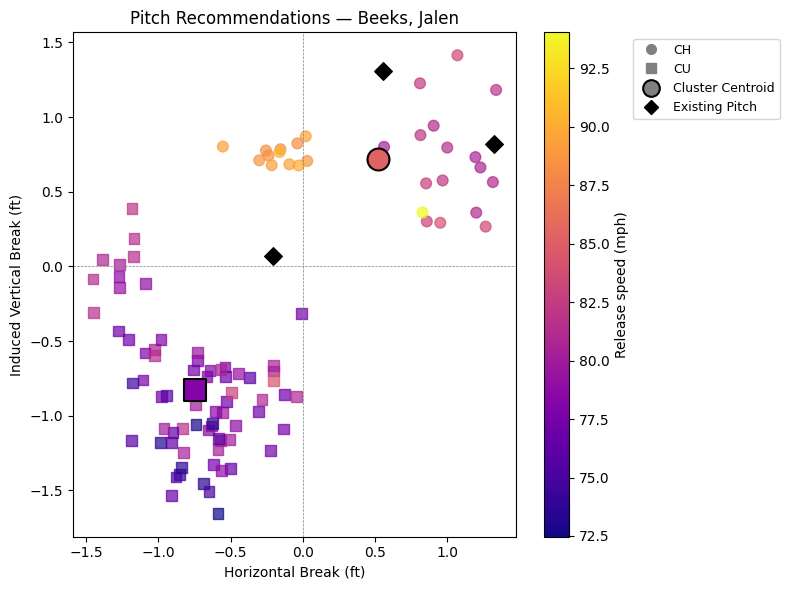

In [32]:
plot_pitch_clusters(j_beeks)

In [33]:
pitch_type_summ[['pfx_x', 'pfx_z']].describe()

,pfx_x,pfx_z
count,18560.000000,18560.000000
mean,-0.129150,0.481719
std,0.886075,0.697991
min,-1.985610,-1.728750
25%,-0.936667,0.074846
50%,-0.195081,0.528848
75%,0.602114,1.033665
max,2.380000,2.260000


In [35]:
pitch_type_summ[abs(pitch_type_summ['pfx_x']) > 2]

,pitch_type,pitcher,player_name,p_throws,game_year,release_speed,release_pos_x,release_pos_z,pfx_x,pfx_z,release_spin_rate,release_extension,release_pos_y,spin_axis,arm_angle,n
18143,ST,672456,"Montero, Keider",R,2025,83.7,-2.59,5.73,2.38,-0.23,2841.0,6.1,54.43,70.0,38.3,1
